# Checkpoint 4 — Questão 1: Logística de emergência após eventos climáticos

**Grupo:** _(preencher: Nome — RA de cada integrante)_  
**SEED do grupo:** definida em `src/config.py` (`SEED_GRUPO`) e registrada no README.

Este notebook executa e explica, na ordem do enunciado, as partes **A** (dados e estruturas), **B** (guloso),
**C** (programação dinâmica), **D** (comparação), **E** (figuras) e **F** (complexidade).
Todo o núcleo algorítmico está em `src/` (Dijkstra, guloso e DP implementados pelo grupo, sem `networkx`/`scipy`/`pulp`).

In [1]:
import sys, time, random
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
from src.gerador_q1 import gerar_instancia, SEED_GRUPO
from src.io_dados import salvar_instancia
from src.grafos import TabelaDistancias, pontos_alcancaveis
from src.greedy import guloso_atendimento, LAMBDA_PADRAO
from src.dynamic_programming import programacao_dinamica_atendimento, preencher_tabela, melhor_valor_1d
from src.comparacao import (comparar_capacidades, estatisticas_por_seed, analisar_contraexemplo, descrever)
from src.visualizacao_q1 import figura_grafo, figura_solucoes, figura_dp, figura_greedy_vs_dp

SEED = SEED_GRUPO
PASTA_FIG = RAIZ / "figures" / "questao1"
print("SEED =", SEED)

SEED = 1


## Parte A — Construção do problema

Os dados são **sintéticos e reprodutíveis**: tudo sai de `random.Random(SEED)` (ver docstring de `src/gerador_q1.py`).

**Modelo.** Vértice 0 = centro de distribuição (CD); vértices 1..20 = pontos de atendimento. Cada ponto tem pessoas afetadas,
prioridade (1–5), demanda mínima de cinco recursos (água, medicamentos, alimentos, higiene, cobertores) convertida em
**carga (kg)**, e **benefício** esperado (∝ pessoas × prioridade). As vias têm distância (km) e podem estar **bloqueadas**.
A malha é uma árvore geradora mínima (garante alcançabilidade) mais vias extras; algumas das extras são declaradas bloqueadas.

In [2]:
inst = gerar_instancia(SEED)
g = inst.grafo
salvar_instancia(inst, RAIZ / "data")

carga_total = sum(p.carga_kg for p in g.pontos_atendimento())
print(f"pontos: {len(g.pontos_atendimento())} | vias: {g.num_arestas} "
      f"({g.num_arestas_disponiveis} disponíveis + {g.num_arestas_bloqueadas} bloqueadas) | "
      f"completo? {g.eh_completo()}")
print(f"carga total demandada = {carga_total} kg | capacidade do veículo = {inst.capacidade} kg\n")
print(f"{'id':>3} {'pessoas':>8} {'prio':>5} {'carga(kg)':>10} {'benefício':>10} {'benef/kg':>9}")
for p in g.pontos_atendimento():
    print(f"{p.id:>3} {p.pessoas:>8} {p.prioridade:>5} {p.carga_kg:>10} {p.beneficio:>10} {p.beneficio/p.carga_kg:>9.2f}")

pontos: 20 | vias: 46 (40 disponíveis + 6 bloqueadas) | completo? False
carga total demandada = 1245 kg | capacidade do veículo = 498 kg

 id  pessoas  prio  carga(kg)  benefício  benef/kg
  1      108     3         28         31      1.11
  2      497     4         90        177      1.97
  3       55     1         21          6      0.29
  4      293     3         68         85      1.25
  5       91     2         26         20      0.77
  6      464     5         94        222      2.36
  7      420     4         86        160      1.86
  8      438     2        104        100      0.96
  9      371     2         86         66      0.77
 10      335     2         82         77      0.94
 11      302     4         65        124      1.91
 12      288     4         59        120      2.03
 13      321     3         77        109      1.42
 14       48     3         14         13      0.93
 15      126     4         32         47      1.47
 16      172     1         42         14      

### Justificativa das estruturas de dados

| Estrutura | Onde | Operação em que é vantajosa (e por quê) |
|---|---|---|
| `dict[int, dict[int, float]]` (lista de adjacência) | `GrafoLogistico._adj` | Grafo **esparso** (E = 40 ≪ V² = 441). Percorrer vizinhos de *u* custa O(grau(u)); peso de uma via em O(1). Matriz V×V gastaria O(V²) de memória e varreria V colunas por vértice. |
| `heapq` (min-heap) | Dijkstra | "Extrair o vértice com menor distância provisória" em O(log V), contra O(V) numa lista. É o que leva Dijkstra a O(E log V). |
| `set[tuple[int,int]]` | vias bloqueadas; pendentes do guloso | Pertinência O(1) média (“esta via está bloqueada?”, “este ponto ainda é candidato?”) e sem duplicatas. |
| `tuple` | chave da aresta `(min,max)`, demanda do ponto | Imutável e *hashable*: pode ser chave de dict/set; a chave canônica faz `(u,v)` e `(v,u)` serem a mesma via. |
| `deque` | BFS de alcançabilidade | `popleft()` O(1); `list.pop(0)` seria O(n). |
| `list[list[int]]` | tabela `DP[i][c]` | Acesso direto por índice O(1) e reconstrução por varredura reversa. |
| `dict` (cache) | `TabelaDistancias` | Guarda o Dijkstra de cada origem já usada: consulta O(1) depois do primeiro cálculo. |

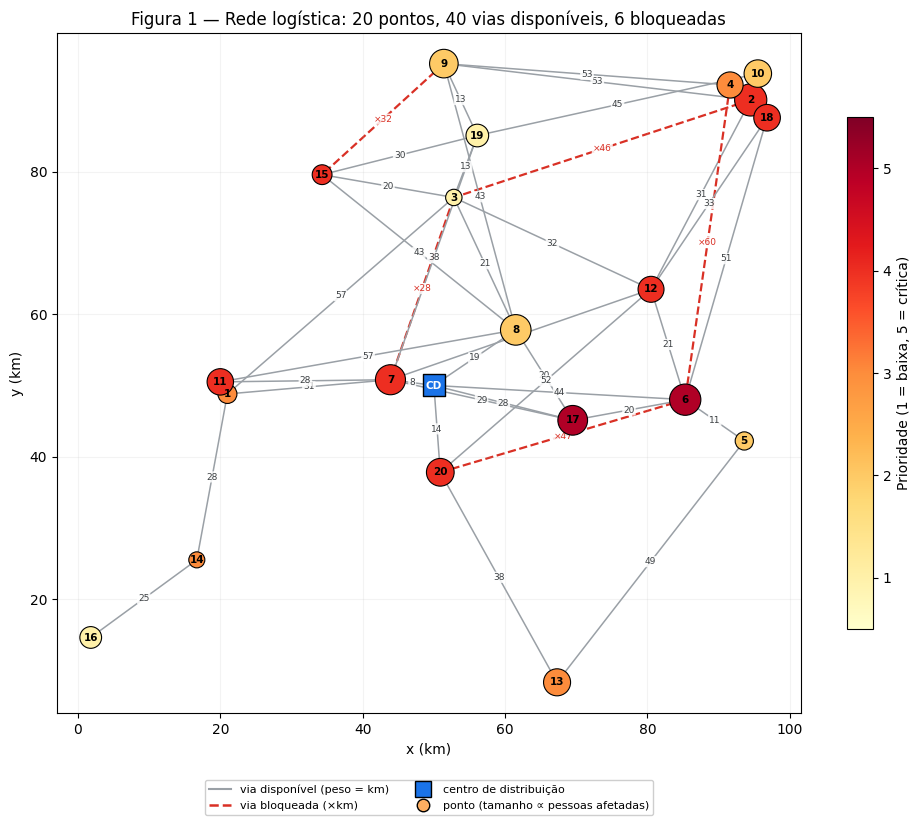

In [3]:
fig1 = figura_grafo(g, PASTA_FIG / 'fig1_grafo.png'); plt.show()

## Parte B — Solução gulosa

**Função de prioridade** (escolha do grupo), calculada a partir da posição atual do veículo:

$$\text{score}(j) \;=\; \frac{\text{benefício}_j}{\text{carga}_j \;+\; \lambda\, d(\text{posição},\,j)}$$

* O denominador é o **custo total, em unidades de capacidade, de obter o benefício de *j***: os kg que ele consome
  mais o custo de chegar lá ($\lambda$ converte km em kg-equivalentes; $d$ = menor caminho por vias *disponíveis*, via Dijkstra).
* O score é, portanto, "benefício por unidade de custo". Para $\lambda=0$ e itens divisíveis isto é a **mochila fracionária**,
  em que escolher a maior razão benefício/peso é **ótimo** (argumento de troca: se uma solução usa $x$ kg de um item de razão menor enquanto
  sobra capacidade de um de razão maior, trocar esses $x$ kg aumenta o benefício em $x(r_{maior}-r_{menor})>0$).
  Logo, a cada passo, gastar capacidade onde ela rende mais é *localmente* a melhor decisão.
* Como os atendimentos são **indivisíveis** (0/1), o argumento de troca deixa de valer e o guloso pode falhar — é o que a Parte D explora.

Por que **não** usar um heap para os scores: eles dependem da posição atual e mudam a cada passo; reconstruir o heap custa O(N),
igual à varredura simples. O heap só compensaria com score estático.

In [4]:
tabela_dist = TabelaDistancias(g)
candidatas = pontos_alcancaveis(g)
print("candidatas (alcançáveis a partir do CD):", len(candidatas), "de", len(g.pontos_atendimento()))

historico = []
guloso = guloso_atendimento(g, inst.capacidade, tabela_dist, candidatas, LAMBDA_PADRAO, historico)

print(f"{'passo':>5} {'de':>4} {'escolhe':>8} {'score':>7} {'cap. restante':>14}   top-3 (score, id)")
for h in historico:
    top = ", ".join(f"({s:.2f}, P{j:02d})" for s, j in h["ranking"])
    print(f"{h['passo']:>5} {h['posicao']:>4} {'P%02d' % h['escolhido']:>8} {h['score']:>7.2f} {h['restante_antes']:>14}   {top}")
print()
print(descrever(guloso))

candidatas (alcançáveis a partir do CD): 20 de 20
passo   de  escolhe   score  cap. restante   top-3 (score, id)
    1    0      P17    2.09            498   (2.09, P17), (1.91, P06), (1.78, P07)
    2   17      P06    2.14            409   (2.14, P06), (1.60, P07), (1.51, P12)
    3    6      P12    1.72            315   (1.72, P12), (1.52, P02), (1.45, P07)
    4   12      P02    1.68            256   (1.68, P02), (1.52, P18), (1.46, P07)
    5    2      P18    1.88            166   (1.88, P18), (1.28, P07), (1.21, P04)
    6   18      P07    1.27            108   (1.27, P07), (1.17, P20), (1.17, P04)
    7    7      P14    0.30             22   (0.30, P14), (0.13, P03)

Guloso: benefício=1020, carga=490 kg, rota=310.1 km, atendidos=7 [P17 -> P06 -> P12 -> P02 -> P18 -> P07 -> P14]


## Parte C — Programação dinâmica (mochila 0/1)

Depois de identificar as regiões candidatas (alcançáveis a partir do CD), escolhemos a combinação que **maximiza o benefício sem ultrapassar a capacidade**.
Sejam $w_i$ a carga (kg) e $b_i$ o benefício da região $i$, e $C$ a capacidade.

1. **Estado:** $DP[i][c]$ = maior benefício usando apenas as $i$ primeiras regiões com $c$ kg de capacidade.
2. **Decisão:** para a região $i$, *não atender* (herda $DP[i-1][c]$) ou *atender* (ganha $b_i$, gasta $w_i$).
3. **Caso-base:** $DP[0][c]=0$ para todo $c$ (sem regiões, sem benefício); $DP[i][0]=0$ decorre da recorrência ($w_i\ge1$).
4. **Recorrência:**
$$DP[i][c]=\begin{cases}DP[i-1][c] & w_i>c\\ \max\big(DP[i-1][c],\;DP[i-1][c-w_i]+b_i\big) & w_i\le c\end{cases}$$
5. **Reconstrução:** de $(N,C)$ para cima: se $DP[i][c]\neq DP[i-1][c]$ a região $i$ foi atendida (só assim o valor poderia crescer) e $c\leftarrow c-w_i$; senão foi ignorada. Custa $O(N)$.

O conjunto ótimo é depois ordenado pelo vizinho mais próximo (ordenar a visita é um TSP, NP-difícil; a DP resolve a *seleção*).

In [5]:
dp, resultado = programacao_dinamica_atendimento(g, inst.capacidade, tabela_dist, candidatas)
print(descrever(dp))
print()
print("regiões escolhidas (índice i da tabela -> id, carga, benefício):")
for i in resultado.escolhidos:
    print(f"  i={i+1:>2} -> P{resultado.candidatas[i]:02d}  carga={resultado.pesos[i]:>3} kg  benefício={resultado.beneficios[i]}")
print("\nvalor ótimo  DP[N][C] =", resultado.beneficio_otimo)
print("verificação pela versão O(C) de memória:", melhor_valor_1d(resultado.pesos, resultado.beneficios, inst.capacidade))

Programação Dinâmica: benefício=1031, carga=497 kg, rota=312.9 km, atendidos=7 [P07 -> P11 -> P14 -> P17 -> P06 -> P12 -> P02]

regiões escolhidas (índice i da tabela -> id, carga, benefício):
  i= 2 -> P02  carga= 90 kg  benefício=177
  i= 6 -> P06  carga= 94 kg  benefício=222
  i= 7 -> P07  carga= 86 kg  benefício=160
  i=11 -> P11  carga= 65 kg  benefício=124
  i=12 -> P12  carga= 59 kg  benefício=120
  i=14 -> P14  carga= 14 kg  benefício=13
  i=17 -> P17  carga= 89 kg  benefício=215

valor ótimo  DP[N][C] = 1031
verificação pela versão O(C) de memória: 1031


## Parte E — Figuras 2 e 3

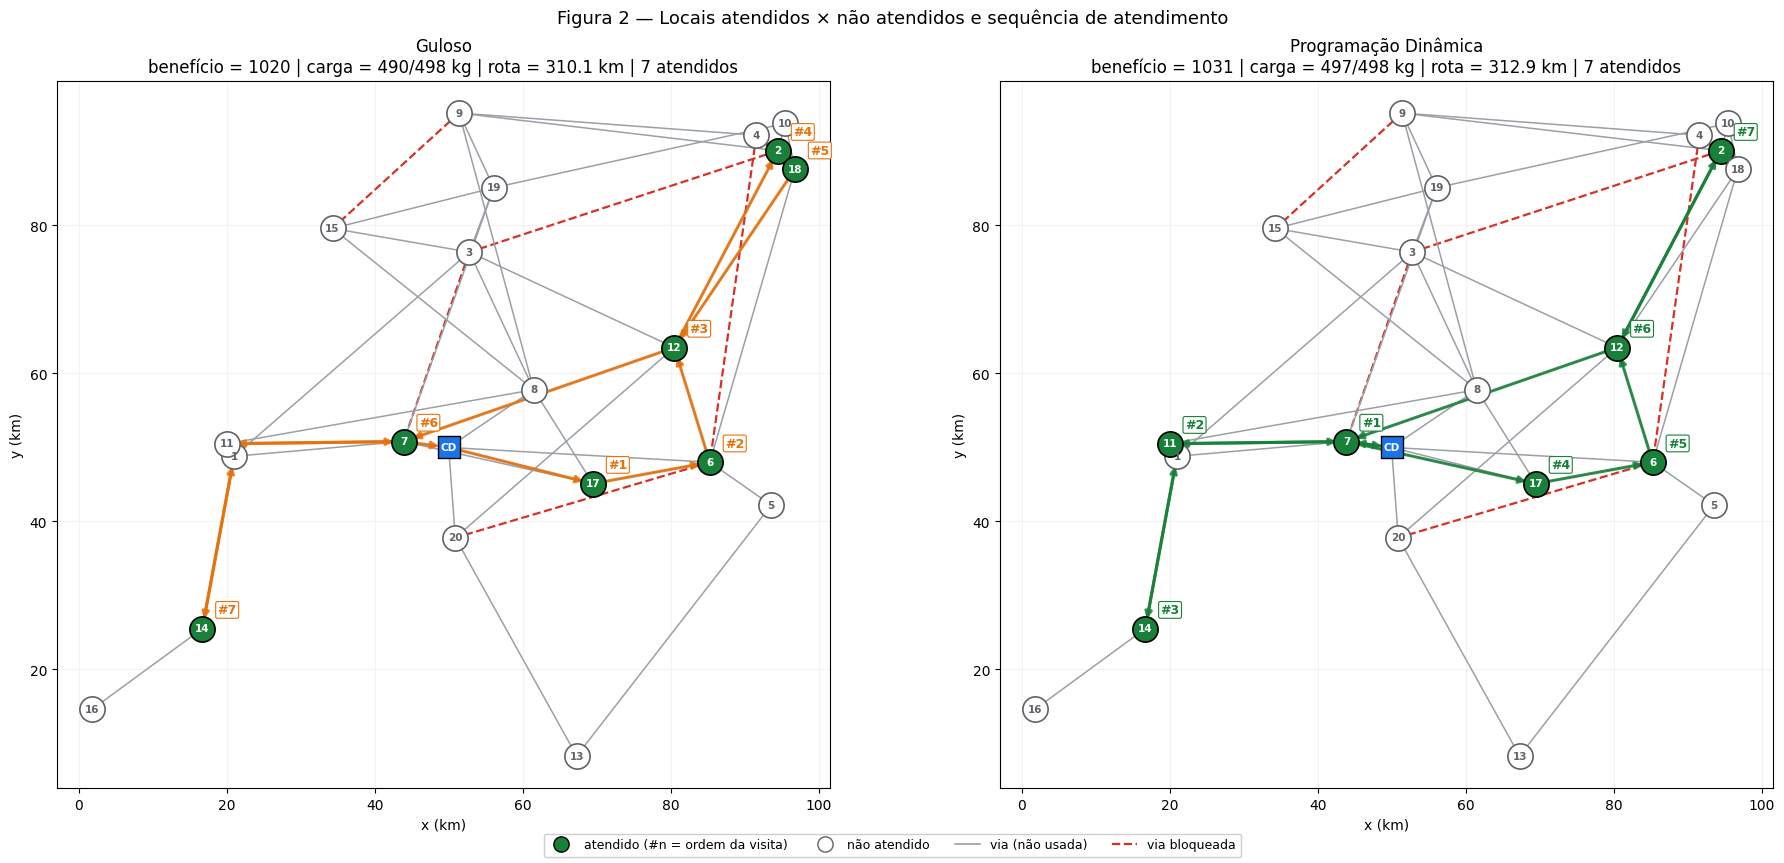

In [6]:
fig2 = figura_solucoes(g, [guloso, dp], tabela_dist, inst.capacidade,
                       "Figura 2 — Locais atendidos × não atendidos e sequência de atendimento",
                       PASTA_FIG / "fig2_solucao.png"); plt.show()

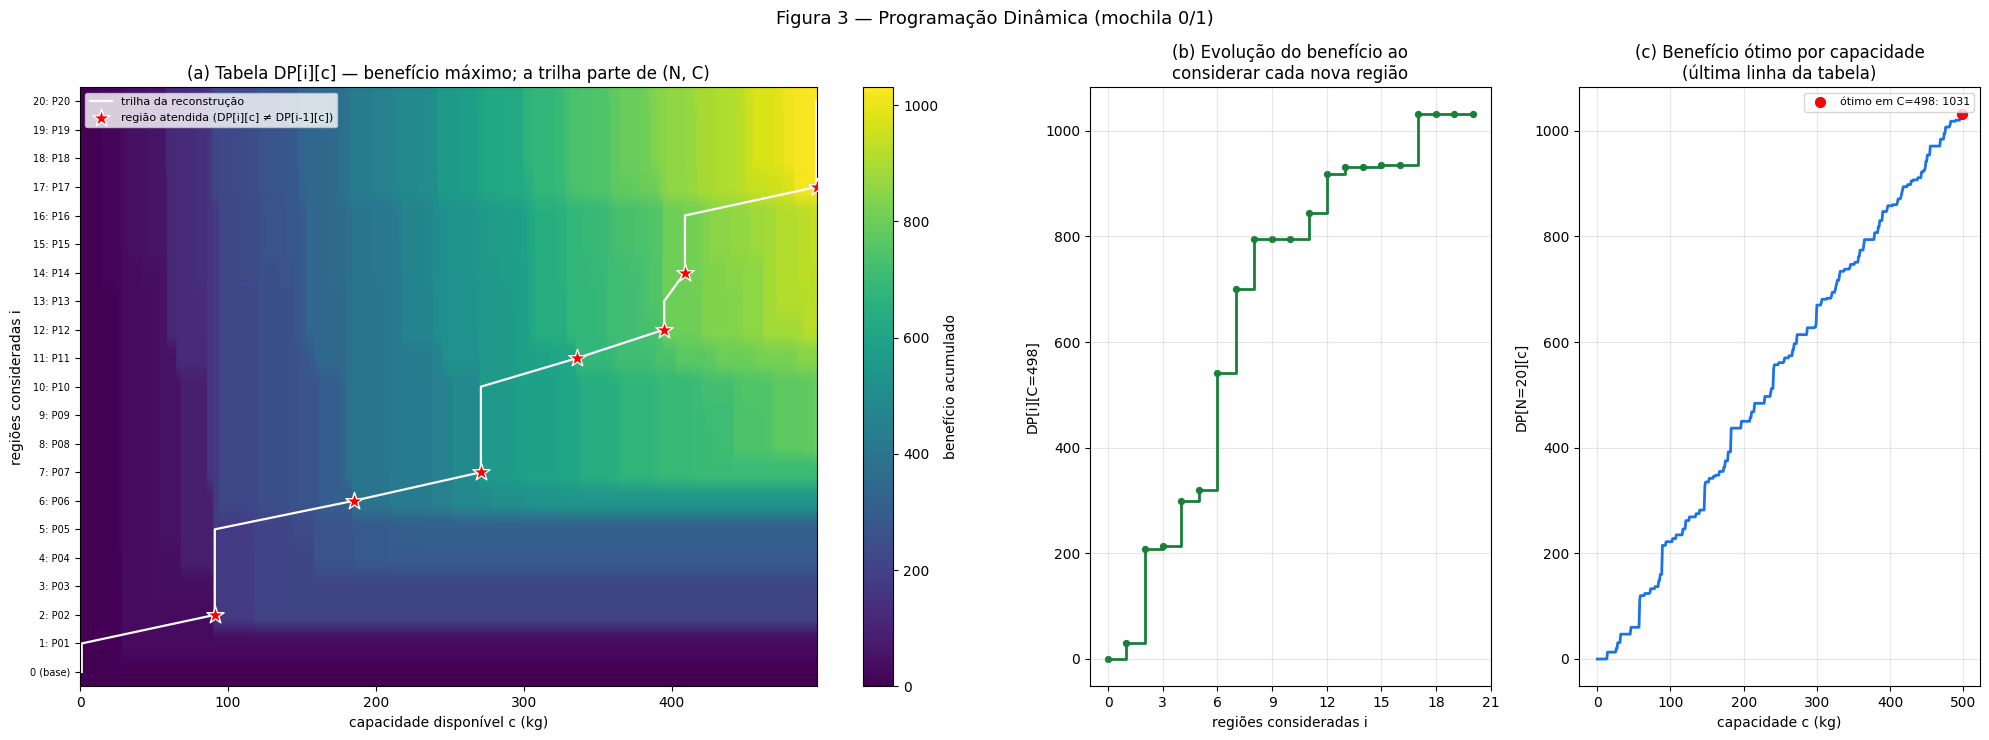

In [7]:
fig3 = figura_dp(resultado, PASTA_FIG / 'fig3_programacao_dinamica.png'); plt.show()

**Como ler a Figura 3.** (a) é a tabela $DP[i][c]$: o benefício cresce para a direita (mais capacidade) e para cima (mais regiões).
A linha branca é a *reconstrução*: parte de $(N,C)$, sobe uma linha por região e, nas estrelas vermelhas, "salta" para a esquerda
$w_i$ kg porque a região foi atendida. (b) mostra o benefício acumulado ao considerar cada região nova para $c=C$. (c) é a última linha:
o ótimo para *qualquer* capacidade — uma só tabela responde a todas.

## Parte D — Comparação Guloso × Programação Dinâmica

Mesmos dados, mesma tabela de distâncias. Investigamos três situações.

Guloso: benefício=1020, carga=490 kg, rota=310.1 km, atendidos=7 [P17 -> P06 -> P12 -> P02 -> P18 -> P07 -> P14]
Programação Dinâmica: benefício=1031, carga=497 kg, rota=312.9 km, atendidos=7 [P07 -> P11 -> P14 -> P17 -> P06 -> P12 -> P02]

Na instância principal: DP − guloso = 11

Varredura de capacidades: guloso ótimo em 51/106; DP superior em 55; maior perda = 45
Guloso ótimo nos extremos (nada cabe / tudo cabe): [0, 12, 24] ... [1224, 1236, 1245]


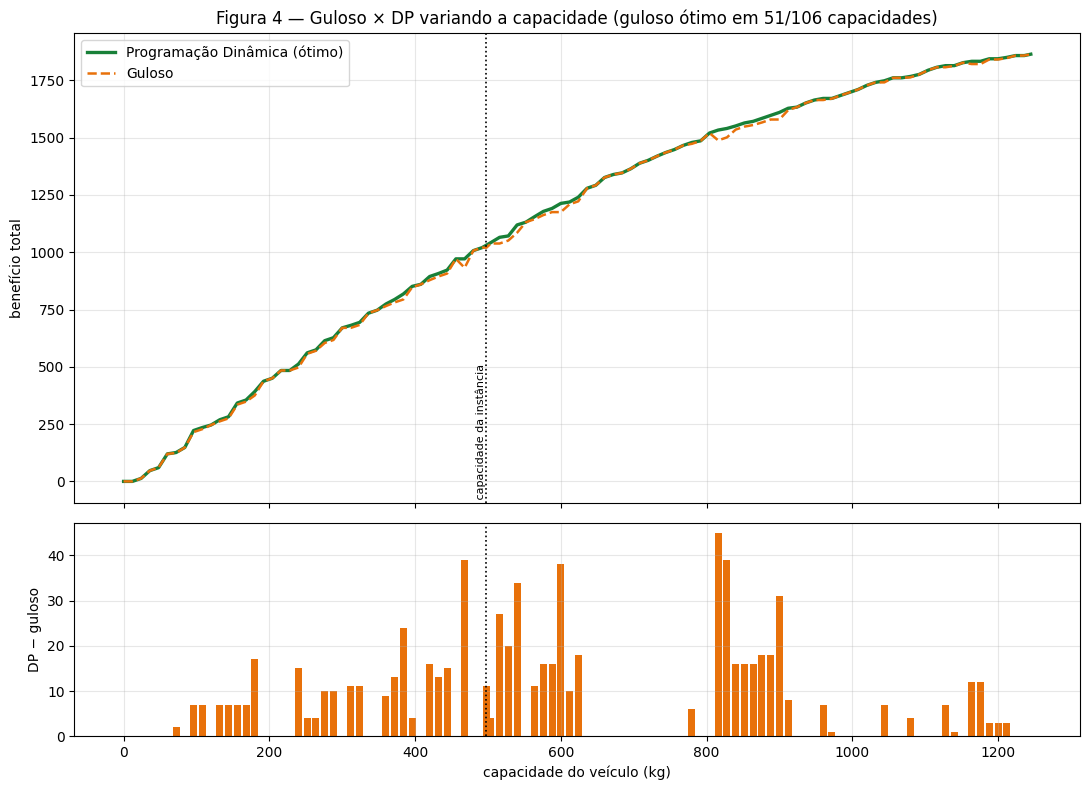

In [8]:
print(descrever(guloso))
print(descrever(dp))
print(f"\nNa instância principal: DP − guloso = {dp.beneficio - guloso.beneficio}")

passo = max(1, carga_total // 100)
capacidades = sorted(set(range(0, carga_total + 1, passo)) | {carga_total, inst.capacidade})
varredura = comparar_capacidades(g, capacidades, LAMBDA_PADRAO)
iguais = [l for l in varredura if l.guloso_otimo]
piores = [l for l in varredura if not l.guloso_otimo]
print(f"\nVarredura de capacidades: guloso ótimo em {len(iguais)}/{len(varredura)}; "
      f"DP superior em {len(piores)}; maior perda = {max(l.diferenca for l in varredura)}")
print("Guloso ótimo nos extremos (nada cabe / tudo cabe):",
      [l.capacidade for l in varredura if l.guloso_otimo][:3], "...", [l.capacidade for l in varredura if l.guloso_otimo][-3:])
fig4 = figura_greedy_vs_dp(varredura, inst.capacidade, PASTA_FIG / "fig4_guloso_vs_dp.png"); plt.show()

In [9]:
stats = estatisticas_por_seed(range(1, 201), LAMBDA_PADRAO)
print(stats)

{'instancias': 200, 'guloso_otimo': 46, 'guloso_subotimo': 154, 'perda_media_pct': 2.1213485389097815, 'perda_maxima_pct': 10.57934508816121, 'seed_pior_caso': 148}


**Leitura.** O guloso é ótimo quando a capacidade é tão pequena que nada cabe ou tão grande que tudo cabe (não há escolha a fazer) e em algumas capacidades
intermediárias em que a ordem por razão "encaixa" bem. Em muitas outras a DP encontra solução superior: escolher o item de maior razão
pode deixar um resto de capacidade que nenhum outro ponto aproveita.

### Contraexemplo próprio (guloso ≠ ótimo)

Capacidade 10 kg; três regiões a 1 km de tudo: **A** (6 kg, benefício 60, razão 10), **B** (5 kg, 45, razão 9), **C** (5 kg, 45, razão 9).

Guloso: benefício=60, carga=6 kg, rota=2.0 km, atendidos=1 [P01]
Programação Dinâmica: benefício=90, carga=10 kg, rota=3.0 km, atendidos=2 [P02 -> P03]

Com capacidade 10 kg, o guloso escolhe primeiro A (score 9.23 > 8.18 de B e C) e sobram 4 kg, insuficientes para B ou C (5 kg cada): benefício 60. A DP percebe que B + C ocupam exatamente 10 kg e valem 90. O guloso otimiza a razão benefício/kg 'agora', mas a indivisibilidade dos atendimentos faz o item de maior razão fragmentar a capacidade e deixar um resto inaproveitável; a DP compara todas as combinações via DP[i][c].

Tabela DP do contraexemplo (linhas i = 0 (base), 1 = A, 2 = B, 3 = C; colunas c = 0..10):
  i=0: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  i=1: [0, 0, 0, 0, 0, 0, 60, 60, 60, 60, 60]
  i=2: [0, 0, 0, 0, 0, 45, 60, 60, 60, 60, 60]
  i=3: [0, 0, 0, 0, 0, 45, 60, 60, 60, 60, 90]


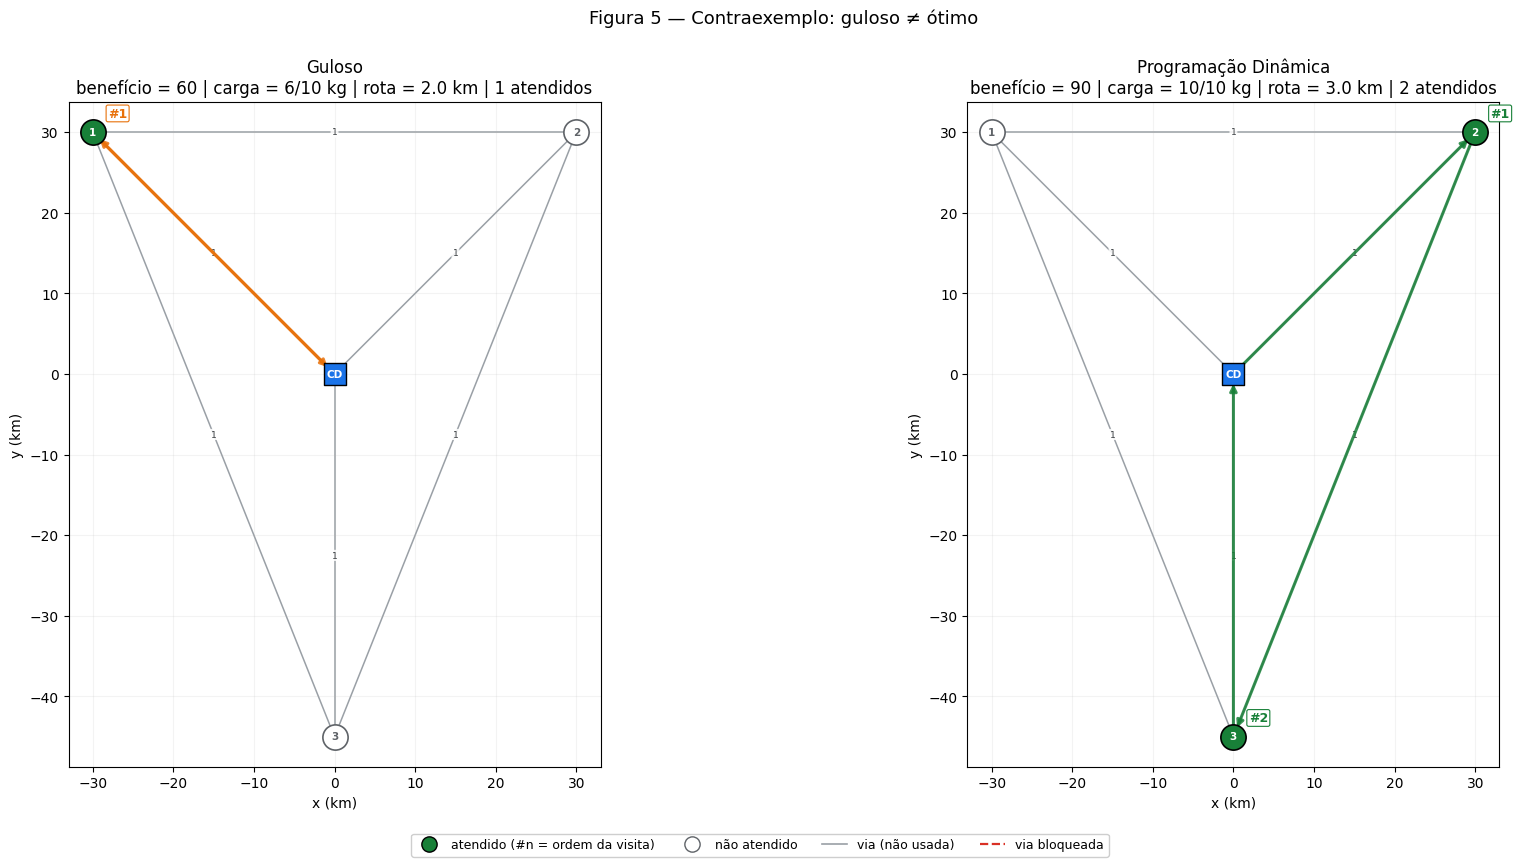

In [10]:
r = analisar_contraexemplo(LAMBDA_PADRAO)
ci = r["instancia"]
print(descrever(r["guloso"]))
print(descrever(r["dp"]))
print()
print(r["explicacao"])
print()
print("Tabela DP do contraexemplo (linhas i = 0 (base), 1 = A, 2 = B, 3 = C; colunas c = 0..10):")
for i, linha in enumerate(r["resultado_dp"].tabela):
    print(f"  i={i}: {linha}")
fig5 = figura_solucoes(ci.grafo, [r["guloso"], r["dp"]], TabelaDistancias(ci.grafo), ci.capacidade,
                       "Figura 5 — Contraexemplo: guloso ≠ ótimo", PASTA_FIG / "fig5_contraexemplo.png",
                       rotulos_vias=True); plt.show()

**Por que o guloso falha (exatamente).** O guloso escolhe A (score $60/6{,}5\approx9{,}23$ contra $45/5{,}5\approx8{,}18$). Sobram 4 kg, e nem B nem C (5 kg) cabem: benefício **60**.
O ótimo é B + C, que ocupam exatamente 10 kg e valem **90**. O limite superior fracionário seria $60+4\cdot9=96$: o guloso é ótimo para a *relaxação fracionária*,
mas o item de maior razão "quebra" a capacidade em um resto que não pode ser fracionado. A DP considera, para cada $(i,c)$, as duas alternativas (atender ou não), então enxerga que abrir mão de A libera espaço para B+C.

## Teste de alteração de entrada (preparação para a defesa)

O professor pode alterar uma via, uma capacidade, uma prioridade... Antes de executar, o grupo deve **prever** o efeito. Exemplo: bloquear a via CD–P07 (8 km).
**Previsão:** as rotas que passavam por ela precisarão de desvio (distância total aumenta); o *benefício* da DP não muda enquanto o conjunto ótimo continuar alcançável e couber na capacidade.

In [11]:
g2 = gerar_instancia(SEED).grafo          # cópia limpa (mesma seed => mesmos dados)
g2.bloquear_aresta(0, 7)                  # <-- alteração: via CD-P07 bloqueada
t2 = TabelaDistancias(g2)                 # nova tabela: a antiga ficou obsoleta
guloso2 = guloso_atendimento(g2, inst.capacidade, t2)
dp2, _ = programacao_dinamica_atendimento(g2, inst.capacidade, t2)
print("ANTES :", descrever(guloso)); print("DEPOIS:", descrever(guloso2)); print()
print("ANTES :", descrever(dp)); print("DEPOIS:", descrever(dp2))

ANTES : Guloso: benefício=1020, carga=490 kg, rota=310.1 km, atendidos=7 [P17 -> P06 -> P12 -> P02 -> P18 -> P07 -> P14]
DEPOIS: Guloso: benefício=1020, carga=490 kg, rota=350.7 km, atendidos=7 [P17 -> P06 -> P12 -> P02 -> P18 -> P07 -> P14]

ANTES : Programação Dinâmica: benefício=1031, carga=497 kg, rota=312.9 km, atendidos=7 [P07 -> P11 -> P14 -> P17 -> P06 -> P12 -> P02]
DEPOIS: Programação Dinâmica: benefício=1031, carga=497 kg, rota=344.5 km, atendidos=7 [P17 -> P06 -> P12 -> P02 -> P07 -> P11 -> P14]


## Parte F — Complexidade

Parâmetros: $V$ vértices, $E$ arestas, $N$ regiões candidatas ($N<V$), $K\le N$ regiões atendidas, $C$ capacidade (kg, inteiro).

**Dijkstra (heap binário, lazy deletion).** Cada via é relaxada no máximo 2 vezes (uma por extremidade) ⇒ até $2E$ inserções no heap, cada uma $O(\log E)=O(\log V)$
(pois $E\le V^2$). Tempo $O(E\log V)$; espaço $O(V+E)$ (vetores de distância/predecessor + heap).

**Guloso.** Precisa do Dijkstra de cada posição visitada (CD + $K$ pontos) ⇒ $O(K\cdot E\log V)$. As decisões: a cada passo varre-se o conjunto de pendentes ($\le N$) calculando o score em $O(1)$,
e há no máximo $N$ passos ⇒ $O(N^2)$. Total: $O(K\,E\log V+N^2)$. Espaço: $O(N)$ para o conjunto + $O(K\cdot V)$ do cache de distâncias.

**Programação dinâmica.** A tabela tem $(N+1)(C+1)$ células e cada uma faz $O(1)$ trabalho (um `max` de dois valores) ⇒ **tempo $\Theta(N\cdot C)$**.
**Espaço** $\Theta(N\cdot C)$ com a tabela completa (necessária para reconstruir a solução) ou $\Theta(C)$ se só o valor ótimo interessa (`melhor_valor_1d`).
A reconstrução custa $O(N)$. É **pseudopolinomial**: depende do *valor* de $C$, não do número de bits para escrevê-lo.
Ordenar a visita por vizinho mais próximo: $O(K^2)$ consultas $O(1)$.

**Pipeline completo:** $O\big(K\,E\log V + N\,C\big)$ tempo e $O(N\,C + K\,V)$ espaço.

Verificação empírica: se $T=\Theta(N\cdot C)$, dobrar $N$ ou $C$ deve aproximadamente dobrar o tempo.

In [12]:
def tempo_dp(n, cap, repeticoes=5):
    rng = random.Random(0)
    pesos = [rng.randint(5, 60) for _ in range(n)]
    ben = [rng.randint(1, 200) for _ in range(n)]
    melhor = float("inf")
    for _ in range(repeticoes):
        t0 = time.perf_counter(); preencher_tabela(pesos, ben, cap); melhor = min(melhor, time.perf_counter() - t0)
    return melhor

print("Fixando C = 1000 e variando N:")
base = None
for n in (40, 80, 160, 320, 640):
    t = tempo_dp(n, 1000); base = base or t
    print(f"  N={n:>4}  células={n*1001:>8}  tempo={t*1000:8.2f} ms  (x{t/base:4.1f} vs N=40; N cresceu x{n/40:.0f})")
print("Fixando N = 160 e variando C:")
base = None
for cap in (500, 1000, 2000, 4000, 8000):
    t = tempo_dp(160, cap); base = base or t
    print(f"  C={cap:>5}  células={160*(cap+1):>8}  tempo={t*1000:8.2f} ms  (x{t/base:4.1f} vs C=500; C cresceu x{cap/500:.0f})")

Fixando C = 1000 e variando N:
  N=  40  células=   40040  tempo=    2.90 ms  (x 1.0 vs N=40; N cresceu x1)
  N=  80  células=   80080  tempo=    5.64 ms  (x 1.9 vs N=40; N cresceu x2)
  N= 160  células=  160160  tempo=   11.14 ms  (x 3.8 vs N=40; N cresceu x4)


  N= 320  células=  320320  tempo=   20.68 ms  (x 7.1 vs N=40; N cresceu x8)
  N= 640  células=  640640  tempo=   40.22 ms  (x13.9 vs N=40; N cresceu x16)
Fixando N = 160 e variando C:


  C=  500  células=   80160  tempo=    4.50 ms  (x 1.0 vs C=500; C cresceu x1)
  C= 1000  células=  160160  tempo=   10.77 ms  (x 2.4 vs C=500; C cresceu x2)
  C= 2000  células=  320160  tempo=   24.76 ms  (x 5.5 vs C=500; C cresceu x4)


  C= 4000  células=  640160  tempo=   54.89 ms  (x12.2 vs C=500; C cresceu x8)


  C= 8000  células= 1280160  tempo=  119.87 ms  (x26.7 vs C=500; C cresceu x16)


O tempo cresce de forma praticamente linear em $N$. Em $C$ o crescimento fica igual ou um pouco acima do linear; atribuímos o excesso a efeitos de memória (a tabela passa de dezenas de milhares para mais de 1 milhão de células, com mais alocação e menos acertos de cache). O número de *operações* continua exatamente $N\cdot(C+1)$, coerente com $\Theta(N\cdot C)$; tempo medido e análise assintótica concordam na tendência, mas o tempo real inclui custos de hardware que a notação O ignora.

**Trade-off guloso × DP.** O guloso é muito mais barato ($O(N^2)$ nas decisões, independente de $C$), mas pode perder benefício (ver Parte D);
a DP paga $\Theta(N\cdot C)$ de tempo e memória para ter a garantia de ótimo. Nesta instância ($N=20$, $C\approx500$) são ~10 mil células — irrisório;
a DP só passaria a incomodar se $C$ (em kg) ou $N$ crescessem por ordens de grandeza.